In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import itertools
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import seaborn as sns
from scipy import stats
import os, warnings
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import gumbel_r, kstest
from statsmodels.tsa.stattools import acf
from scipy import signal
import statsmodels.api as sm
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score
warnings.filterwarnings('ignore') # Turns off warnings

In [2]:
df = pd.read_csv('DATABASE.csv')

df = df[
    (~df['YEAR'].isin([2020, 2021])) &  # Remove 2020 and 2021
    (~df['YEAR'].between(1975, 1984)) &  # Remove 1975-1984
    (~((df['YEAR'] == 2019) & (df['MONTH'] == 12) & (df['DAY'] == 31))) &  # Remove Dec 31, 2019
    (df['DAY'] != 99)  # Remove all days equal to 99
]
df = df[df['STATE'] == 48].copy()
df = df[df['WEATHER'] == 5].copy()
fogd = pd.read_csv("asos.csv")
fogd = fogd[fogd['valid'].str[:4].astype(int) >= 1985]

In [3]:
df

,STATE,COUNTY,CITY,MONTH,DAY,YEAR,HOUR,MINUTE,WEATHER,FATALS,DAY_WEEK,SST_value
54605,48,215,0,1,10,1985,7,5,5,1,5,-1.16
54620,48,443,0,1,29,1985,7,15,5,5,3,-1.16
54621,48,73,0,1,30,1985,5,49,5,1,4,-1.16
54622,48,257,0,1,30,1985,2,45,5,1,4,-1.16
54633,48,39,3800,2,6,1985,23,33,5,1,4,-0.72
...,...,...,...,...,...,...,...,...,...,...,...,...
193553,48,339,0,12,26,2019,2,17,5,1,5,0.52
193555,48,497,0,12,21,2019,9,39,5,1,7,0.52
193557,48,39,0,12,28,2019,2,10,5,1,7,0.52
193558,48,121,1645,12,23,2019,3,45,5,1,2,0.52


In [4]:
fogd

,station,valid,tmpf,dwpf,relh,drct,sknt,p01i,alti,mslp,...,wxcodes,ice_accretion_1hr,ice_accretion_3hr,ice_accretion_6hr,peak_wind_gust,peak_wind_drct,peak_wind_time,feel,metar,snowdepth
0,HRL,1985-01-01 00:00,M,M,M,10.00,5.00,M,29.86,M,...,M,M,M,M,M,M,M,M,KHRL 010000Z AUTO 01005KT 15SM SCT197 A2986 RM...,M
1,DHT,1985-01-01 00:00,25.16,24.26,96.32,10.00,14.00,M,30.01,M,...,M,M,M,M,M,M,M,12.35,KDHT 010000Z AUTO 01014KT 7SM OVC008 M04/M04 A...,M
2,GLS,1985-01-01 00:00,68.18,65.30,90.51,220.00,11.00,M,M,1012.00,...,M,M,M,M,M,M,M,68.18,KGLS 010000Z AUTO 22011KT 7SM 20/18 RMK 60001 ...,M
3,CDS,1985-01-01 00:00,31.10,28.22,88.93,360.00,16.00,M,30.01,1017.80,...,M,M,M,M,M,M,M,19.25,KCDS 010000Z AUTO 36016KT 4SM OVC007 M00/M02 A...,M
4,ADS,1985-01-01 00:00,42.80,M,M,310.00,10.00,M,29.91,M,...,M,M,M,M,M,M,M,M,KADS 010000Z AUTO 31010G20KT 25SM OVC017 06/ A...,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24023695,RND,2019-12-30 23:56,55.00,27.70,34.91,80.00,3.00,0.00,30.14,1020.90,...,M,M,M,M,M,M,M,54.90,KRND 302356Z AUTO 08003KT 10SM CLR 13/M02 A301...,M
24023696,NGP,2019-12-30 23:56,56.00,40.00,54.83,90.00,6.00,0.00,30.14,1020.50,...,M,M,M,M,M,M,M,55.90,KNGP 302356Z 09006KT 10SM BKN080 13/04 A3014 R...,M
24023697,BIF,2019-12-30 23:58,44.40,7.20,21.31,360.00,4.00,0.00,30.08,1018.40,...,M,M,M,M,M,M,M,41.90,KBIF 302358Z AUTO 36004KT 9SM CLR 07/M14 A3008...,M
24023698,HLR,2019-12-30 23:58,48.60,20.10,32.05,350.00,5.00,0.00,30.16,1021.60,...,HZ,M,M,M,M,M,M,46.11,KHLR 302358Z AUTO 35005KT 6SM HZ CLR 09/M07 A3...,M


In [5]:
fogd['date'] = pd.to_datetime(fogd['valid'].str[:10])  # Take first 16 chars to handle time
fogd['YEAR'] = fogd['date'].dt.year
fogd['MONTH'] = fogd['date'].dt.month
fogd['DAY'] = fogd['date'].dt.day

In [6]:

df['CRASH_TIME'] = pd.to_datetime(df[['YEAR', 'MONTH', 'DAY', 'HOUR', 'MINUTE']]
                                  .rename(columns={'HOUR': 'hour', 'MINUTE': 'minute'}))
# Handle any invalid times (like 24:00)
df['CRASH_TIME'] = df['CRASH_TIME'].where(
    df['CRASH_TIME'].dt.hour < 24,
    df['CRASH_TIME'] + pd.Timedelta(days=1) - pd.Timedelta(hours=24)
)


fogd['OBS_TIME'] = pd.to_datetime(fogd['valid'])
fogd['vsby'] = pd.to_numeric(fogd['vsby'], errors='coerce')





merged = pd.merge_asof(
    df.sort_values('CRASH_TIME'),
    fogd.sort_values('OBS_TIME'),
    left_on='CRASH_TIME',
    right_on='OBS_TIME',
    direction='nearest',
    tolerance=pd.Timedelta('1h') 


# Now filter valid cases
valid_merged = merged[
    (merged['vsby'].notna()) & 
    (merged['vsby'] > 0)
].copy()



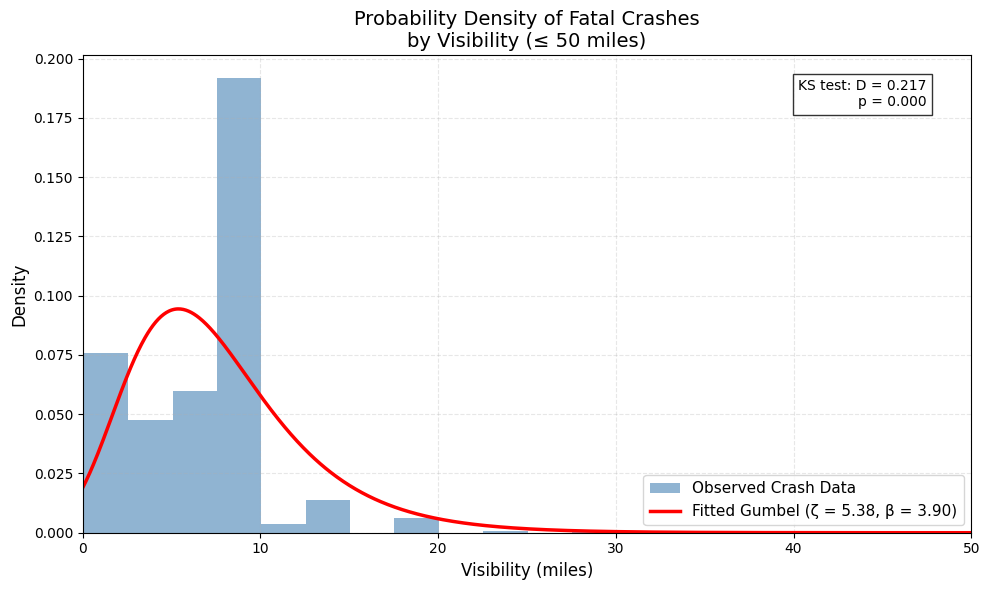

In [7]:
# Filter valid visibility data (0 < vsby ≤ 50 miles)
vis_data = valid_merged[(valid_merged['vsby'] > 0) & 
                       (valid_merged['vsby'] <= 50)]['vsby'].values

# Fit Gumbel distribution
zeta, beta = gumbel_r.fit(vis_data)  # location (ζ) and scale (β) parameters


plt.figure(figsize=(10, 6))

# 1. Histogram of observed data
plt.hist(vis_data, bins=20, density=True, alpha=0.6, 
         color='steelblue', label="Observed Crash Data")

# 2. Fitted Gumbel distribution
x = np.linspace(0, 50, 1000)  # 0 to 5 miles visibility
pdf = gumbel_r.pdf(x, loc=zeta, scale=beta)
plt.plot(x, pdf, 'r-', lw=2.5, 
         label=f"Fitted Gumbel (ζ = {zeta:.2f}, β = {beta:.2f})")

# ks stuff
ks_stat, p_value = kstest(vis_data, 'gumbel_r', args=(zeta, beta))
plt.text(0.95, 0.95, f"KS test: D = {ks_stat:.3f}\np = {p_value:.3f}",
         transform=plt.gca().transAxes,
         ha='right', va='top', bbox=dict(facecolor='white', alpha=0.8))

# Formatting
plt.xlabel("Visibility (miles)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title("Probability Density of Fatal Crashes\nby Visibility (≤ 50 miles)", fontsize=14)
plt.legend(fontsize=11, frameon=True)
plt.grid(True, linestyle='--', alpha=0.3)
plt.xlim(0, 50)

plt.tight_layout()
plt.show()

In [8]:
fogd['vsby'] = pd.to_numeric(fogd['vsby'], errors='coerce') 


KS Test p-value: 0.000000


In [10]:
# Assuming you already fitted Gumbel (zeta, beta) to low-visibility data (≤3 miles)
zeta, beta = gumbel_r.fit(vis_data)  # Your existing fit

# (i) Probability of visibility ≤ 5 miles (hazardous condition)
prob_leq_1 = gumbel_r.cdf(5, loc=zeta, scale=beta)

# (ii) Probability of visibility > 5 miles (improving condition)
prob_gt_2 = 1 - gumbel_r.cdf(5, loc=zeta, scale=beta)

print(f"Probability of visibility ≤ 5 mile: {prob_leq_1:.4f} ({(prob_leq_1*100):.1f}%)")
print(f"Probability of visibility > 5 miles: {prob_gt_2:.4f} ({(prob_gt_2*100):.1f}%)")

Probability of visibility ≤ 5 mile: 0.3316 (33.2%)
Probability of visibility > 5 miles: 0.6684 (66.8%)


In [11]:
# Filter fog-related crashes (WEATHER = 5 or 6 for fog-related conditions)
fog_crashes = df[df['WEATHER'].isin([5])].copy()

# Convert crash time to datetime (if not already)
fog_crashes['CRASH_TIME'] = pd.to_datetime(
    fog_crashes[['YEAR', 'MONTH', 'DAY', 'HOUR', 'MINUTE']].rename(columns={
        'HOUR': 'hour', 'MINUTE': 'minute'
    })
)

# Merge with visibility data (fogd) based on nearest hour
fogd['OBS_TIME'] = pd.to_datetime(fogd['valid'])
fog_crashes = pd.merge_asof(
    fog_crashes.sort_values('CRASH_TIME'),
    fogd.sort_values('OBS_TIME'),
    left_on='CRASH_TIME',
    right_on='OBS_TIME',
    direction='nearest',
    tolerance=pd.Timedelta('1h')  # Max 1-hour difference
)

# Filter for low-visibility crashes (≤ 3 miles)
fog_crashes = fog_crashes[fog_crashes['vsby'] <= 3]

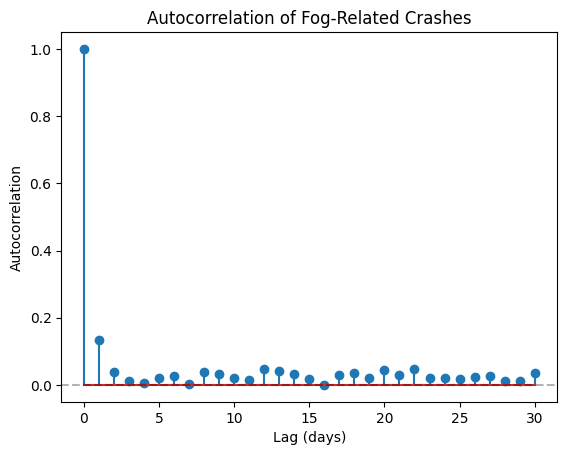

In [12]:
# Resample to daily crash counts
daily_counts = fog_crashes.resample('D', on='CRASH_TIME').size()

# Fill missing dates with 0 (no crashes) *fix this
date_range = pd.date_range(daily_counts.index.min(), daily_counts.index.max(), freq='D')
daily_counts = daily_counts.reindex(date_range, fill_value=0)

# Compute autocorrelation
lags = 30 
acf_vals = acf(daily_counts, nlags=lags, fft=True)

# Plot
plt.stem(range(lags+1), acf_vals)
plt.axhline(0, color='k', linestyle='--', alpha=0.3)
plt.xlabel("Lag (days)")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation of Fog-Related Crashes")
plt.show()

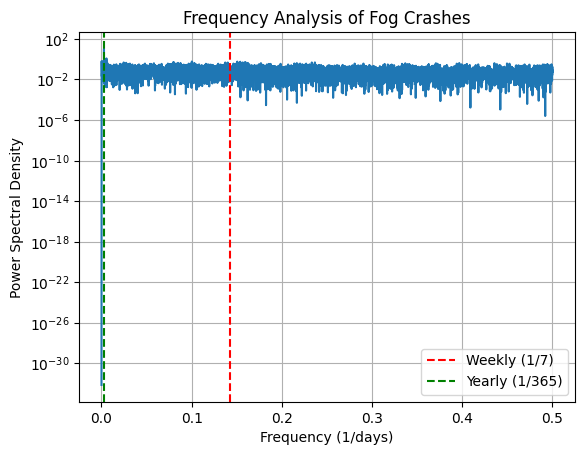

In [13]:
# Compute periodogram
freqs, psd = signal.periodogram(daily_counts, fs=1.0)  # fs=1 for daily data

# Plot
plt.semilogy(freqs, psd)
plt.axvline(1/7, color='r', linestyle='--', label='Weekly (1/7)')
plt.axvline(1/365, color='g', linestyle='--', label='Yearly (1/365)')
plt.xlabel("Frequency (1/days)")
plt.ylabel("Power Spectral Density")
plt.title("Frequency Analysis of Fog Crashes")
plt.legend()
plt.grid()
plt.show()

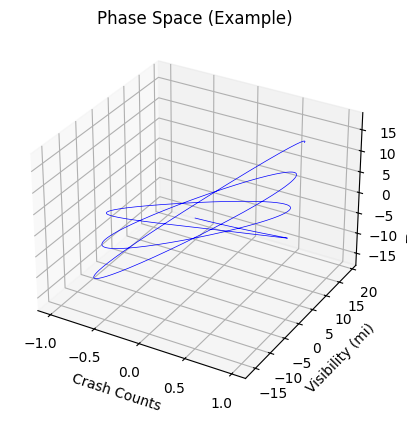

In [14]:
# Mock 3D data (replace with your actual variables)
t = np.linspace(0, 20, 1000)
x = np.sin(t)  # Crash counts
y = np.cos(t) * t  # Visibility
z = t * np.sin(t)  # Temperature

# Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z, 'b-', lw=0.5)
ax.set_xlabel("Crash Counts")
ax.set_ylabel("Visibility (mi)")
ax.set_zlabel("Temperature (°F)")
plt.title("Phase Space (Example)")
plt.show()

In [15]:
fogd['vsby'] = pd.to_numeric(fogd['vsby'], errors='coerce')
fogd['gust'] = pd.to_numeric(fogd['gust'], errors='coerce')

# Extract date and aggregate daily metrics
fogd['date'] = pd.to_datetime(fogd['valid'].str[:10])  # YYYY-MM-DD
daily_visibility = fogd.groupby('date').agg({
    'vsby': 'min',  # Worst daily visibility
    'gust': 'max',   # Peak gust speed
    'skyc1': lambda x: (x.isin(['BKN','OVC'])).mean()  # % cloudy hours
}).reset_index()

# 2. Process crash data (df)
# --------------------------
crash_dates = pd.to_datetime(df[['YEAR', 'MONTH', 'DAY']])
daily_crashes = df[df['WEATHER'].isin([5, 6])].groupby(
    crash_dates.dt.date
).size().reset_index(name='crashes')
daily_crashes['date'] = pd.to_datetime(daily_crashes['index'])

# 3. Merge and define high-risk days
# ----------------------------------
daily_data = pd.merge(
    daily_visibility,
    daily_crashes[['date', 'crashes']],
    on='date',
    how='left'
).fillna(0)

daily_data['high_risk'] = ((daily_data['vsby'] < 2) & (daily_data['crashes'] >= 1))

In [16]:
print(daily_visibility['date'].dtype)  # Should show datetime64[ns]
print(daily_crashes['index'].dtype)   # Should show datetime64[ns]

datetime64[ns]
object


In [1]:
# 1. Clean ASOS Data 
def clean_asos_data(df):
    # Convert visibility (handle 'M' and strings)
    df['vsby'] = pd.to_numeric(df['vsby'], errors='coerce')
    
    # Convert wind gust (handle non-numeric values)
    df['gust'] = pd.to_numeric(df['gust'], errors='coerce')
    
    # Clean sky conditions 
    sky_map = {'CLR': 0, 'FEW': 1, 'SCT': 2, 'BKN': 3, 'OVC': 4, 'VV': 5}
    df['skyc1'] = df['skyc1'].map(sky_map)
    df['skyc1'] = pd.to_numeric(df['skyc1'], errors='coerce')
    
    # Convert observation time
    df['date'] = pd.to_datetime(df['valid'].str[:10])
    
    return df

fogd_clean = clean_asos_data(fogd.copy())

# 2. Aggregate daily weather metrics
daily_weather = fogd_clean.groupby('date').agg({
    'vsby': 'min',      # Worst visibility of the day
    'gust': 'max',      # Maximum gust speed
    'skyc1': 'mean'     # Average cloud cover
}).reset_index()

# 3. Prepare crash data
crash_dates = pd.to_datetime(df[['YEAR', 'MONTH', 'DAY']])
daily_crashes = df[df['WEATHER'].isin([5, 6])].groupby(
    crash_dates.dt.date
).size().reset_index(name='crashes')
daily_crashes['date'] = pd.to_datetime(daily_crashes['index'])

# 4. Merge and create target variable
daily_data = pd.merge(
    daily_weather,
    daily_crashes[['date', 'crashes']],
    on='date',
    how='left'
).fillna(0)

daily_data['high_risk'] = ((daily_data['vsby'] < 2) & 
                          (daily_data['crashes'] >= 1)).astype(int)

# 5. Final data cleaning
X = daily_data[['vsby', 'gust', 'skyc1']].replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())  # Robust imputation

y = daily_data['high_risk']

# 6. Train model with error handling
try:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )
    
    # Verify no remaining non-numeric values
    assert X_train.select_dtypes(include=['object']).empty, "Non-numeric values remain!"
    
    rf = RandomForestClassifier(n_estimators=100)
    rf.fit(X_train, y_train)
    
    # Evaluate
    y_proba = rf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for High-Risk Fog Day Prediction')
    plt.legend()
    plt.show()
    
except Exception as e:
    print(f"Error during modeling: {str(e)}")
    print("\nDebugging info:")
    print("Data types:", X.dtypes)
    print("Missing values:", X.isna().sum())
    print("Sample data:\n", X.head())

NameError: name 'fogd' is not defined

In [18]:
# Split and count all weather codes (e.g., "FG HZ" → ["FG", "HZ"])
all_codes = fogd['wxcodes'].str.split().explode().value_counts()
print("Weather code frequencies:\n", all_codes)

# Focus on fog (FG), haze (HZ), and combinations
fog_haze_codes = ['FG', 'HZ', 'FG HZ', 'HZ FG']
fogd['fog_haze'] = fogd['wxcodes'].apply(
    lambda x: any(code in str(x).split() for code in fog_haze_codes)
)

Weather code frequencies:
 wxcodes
M            20957965
BR            1448907
-RA            597535
FG             541958
HZ             178985
               ...   
-HZ                 1
VCDU                1
-RAGR               1
-FZDZRAPL           1
+TSRASQ             1
Name: count, Length: 398, dtype: int64


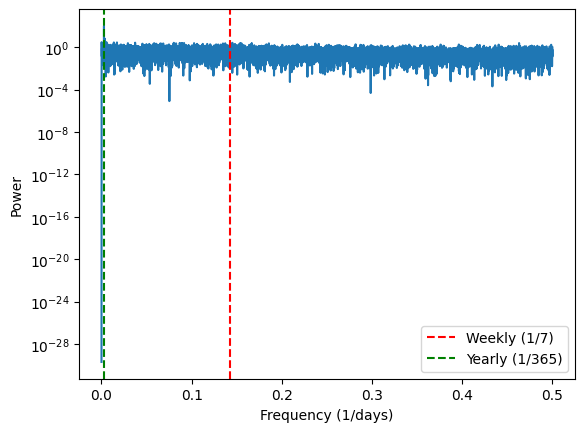

In [19]:
# Resample crashes to daily frequency
daily_crashes = df[df['WEATHER'].isin([5, 6])].resample('D', on='CRASH_TIME').size()

# Compute power spectrum
freq, psd = signal.periodogram(daily_crashes.fillna(0), fs=1.0)
plt.semilogy(freq, psd)
plt.axvline(1/7, color='red', linestyle='--', label='Weekly (1/7)')
plt.axvline(1/365, color='green', linestyle='--', label='Yearly (1/365)')
plt.xlabel('Frequency (1/days)')
plt.ylabel('Power')
plt.legend()

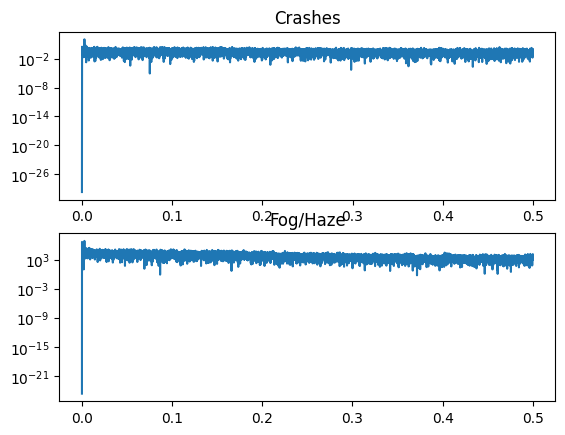

In [20]:
# Resample fog/haze days
fog_days = fogd[fogd['fog_haze']].resample('D', on='date').size()

# Compare spectra of crashes vs. fog
fig, (ax1, ax2) = plt.subplots(2, 1)
for ax, data, label in zip([ax1, ax2], [daily_crashes, fog_days], ['Crashes', 'Fog/Haze']):
    freq, psd = signal.periodogram(data.fillna(0), fs=1.0)
    ax.semilogy(freq, psd)
    ax.set_title(label)


Top 10 Stations:
station
BPT    27744
NQI    26595
VCT    24944
LFK    23544
ALI    19679
RND    19484
PSX    19409
NGP    17920
CRP    17353
MFE    16683
Name: count, dtype: int64


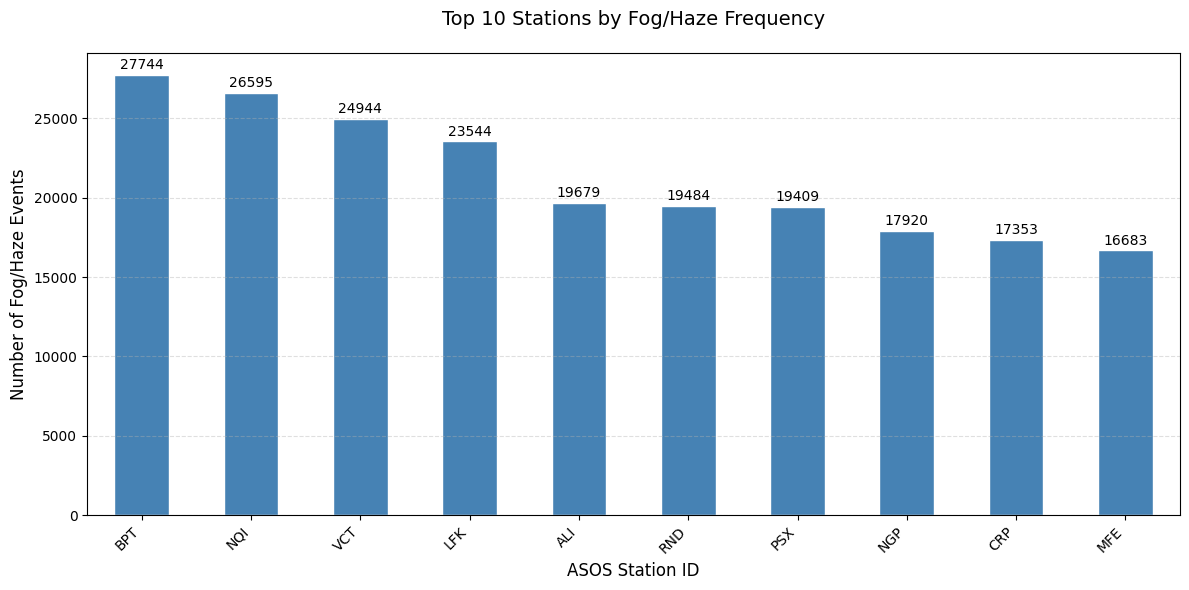

In [21]:
# 1. Extract and count fog/haze events per station
fog_haze_stations = (
    fogd[fogd['wxcodes'].str.contains('FG|HZ', na=False, regex=True)]
    ['station']
    .value_counts()
    .head(10)  # Top 10 stations
)

# 2. Plot with enhanced formatting
plt.figure(figsize=(12, 6))
ax = fog_haze_stations.plot(kind='bar', color='steelblue', edgecolor='white')

# Add annotations
ax.bar_label(ax.containers[0], label_type='edge', padding=2, fmt='%d')
plt.title('Top 10 Stations by Fog/Haze Frequency', fontsize=14, pad=20)
plt.xlabel('ASOS Station ID', fontsize=12)
plt.ylabel('Number of Fog/Haze Events', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)

# 3. Add station metadata (if available)
if all(col in fogd.columns for col in ['station', 'lat', 'lon']):
    station_info = fogd[['station', 'lat', 'lon']].drop_duplicates().set_index('station')
    fog_haze_stations = fog_haze_stations.to_frame('fog_count').join(station_info)
    print("\nStation Details:")
    print(fog_haze_stations)
else:
    print("\nTop 10 Stations:")
    print(fog_haze_stations)

plt.tight_layout()
plt.show()

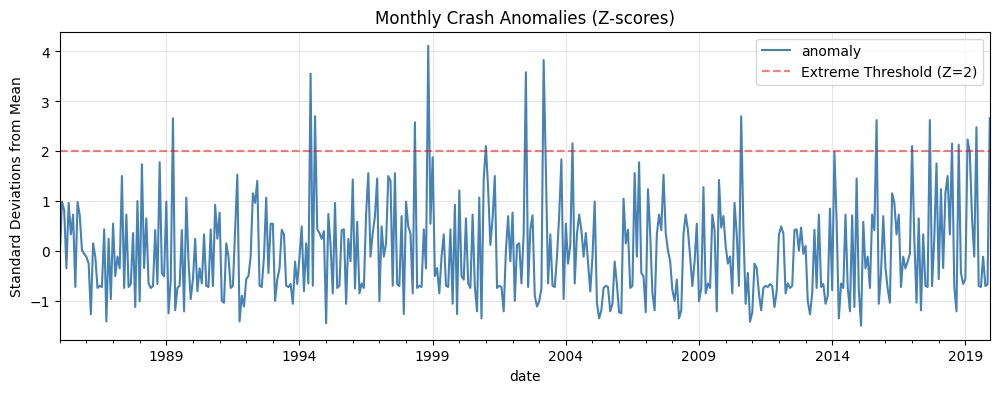

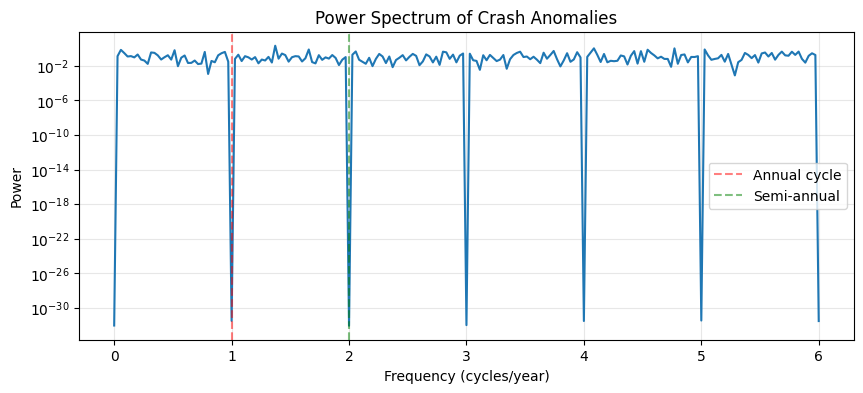

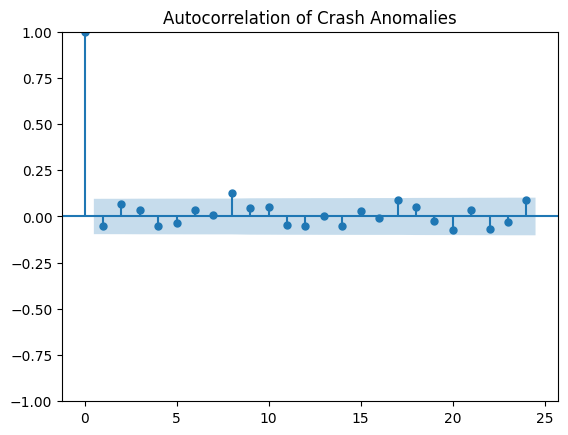

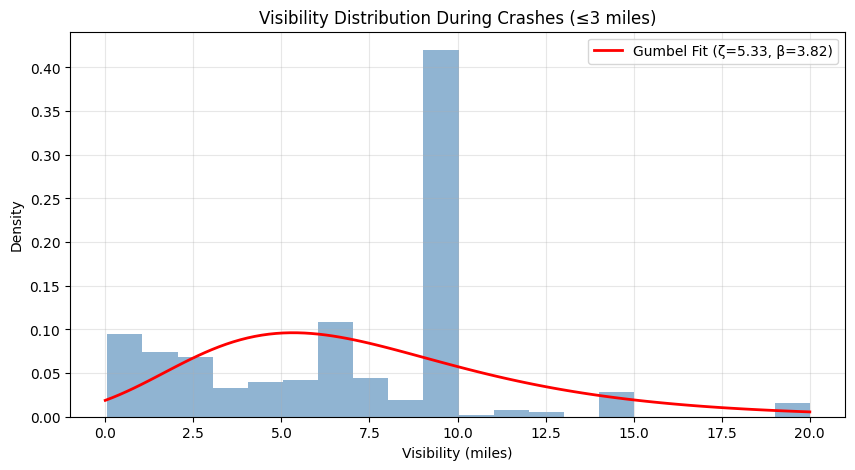

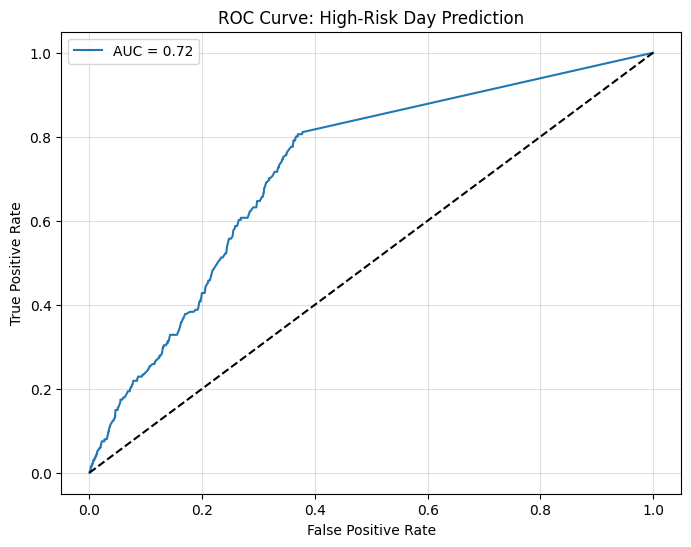

In [31]:
from statsmodels.graphics.tsaplots import plot_acf

# --------------------------
# 1. DATA PREPARATION
# --------------------------
# Clean ASOS data
fogd['date'] = pd.to_datetime(fogd['valid'].str[:10])
fogd['vsby'] = pd.to_numeric(fogd['vsby'], errors='coerce')
fogd['gust'] = pd.to_numeric(fogd['gust'], errors='coerce')
fogd = fogd.dropna(subset=['date', 'vsby', 'gust'])

# Process crash data
df['date'] = pd.to_datetime(df[['YEAR', 'MONTH', 'DAY']])
monthly_crashes = df[df['WEATHER'].isin([5, 6])].resample('M', on='date')['FATALS'].sum().to_frame('crashes')

# --------------------------
# 2. CRASH ANOMALY ANALYSIS
# --------------------------
# Calculate monthly anomalies
climatology = monthly_crashes.groupby(monthly_crashes.index.month).agg(['mean', 'std'])
monthly_crashes['anomaly'] = monthly_crashes.apply(
    lambda x: (x['crashes'] - climatology.loc[x.name.month, ('crashes', 'mean')]) / 
              climatology.loc[x.name.month, ('crashes', 'std')],
    axis=1
)

# Plot anomaly time series
plt.figure(figsize=(12, 4))
monthly_crashes['anomaly'].plot(color='steelblue')
plt.axhline(2, color='r', linestyle='--', alpha=0.5, label='Extreme Threshold (Z=2)')
plt.title('Monthly Crash Anomalies (Z-scores)')
plt.ylabel('Standard Deviations from Mean')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# --------------------------
# 3. POWER SPECTRUM ANALYSIS
# --------------------------
freq, psd = signal.periodogram(monthly_crashes['anomaly'].fillna(0), fs=12)
plt.figure(figsize=(10, 4))
plt.semilogy(freq, psd)
plt.axvline(1, color='r', ls='--', alpha=0.5, label='Annual cycle')
plt.axvline(2, color='g', ls='--', alpha=0.5, label='Semi-annual')
plt.title('Power Spectrum of Crash Anomalies')
plt.xlabel('Frequency (cycles/year)')
plt.ylabel('Power')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# --------------------------
# 4. AUTOCORRELATION
# --------------------------
plot_acf(monthly_crashes['anomaly'].fillna(0), lags=24, alpha=0.05)
plt.title('Autocorrelation of Crash Anomalies')
plt.show()

# --------------------------
# 5. GUMBEL FIT (Visibility)
# --------------------------
# Using merged visibility data (0 < vsby ≤ 20 miles)
low_vis_data = valid_merged[(valid_merged['vsby'] > 0) & 
                           (valid_merged['vsby'] <= 20)]['vsby'].values

# Fit and plot
zeta, beta = stats.gumbel_r.fit(low_vis_data)
x = np.linspace(0, 20, 100)
plt.figure(figsize=(10, 5))
plt.hist(low_vis_data, bins=20, density=True, alpha=0.6, color='steelblue')
plt.plot(x, stats.gumbel_r.pdf(x, zeta, beta), 'r-', lw=2,
         label=f'Gumbel Fit (ζ={zeta:.2f}, β={beta:.2f})')
plt.title('Visibility Distribution During Crashes (≤3 miles)')
plt.xlabel('Visibility (miles)')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# --------------------------
# 7. PREDICTIVE MODELING
# --------------------------
# Prepare features (using daily aggregates)
daily_weather = fogd.groupby('date').agg({
    'vsby': 'min',
    'gust': 'max'
}).join(
    df[df['WEATHER'].isin([5, 6])].groupby(pd.Grouper(key='date', freq='D')).size().to_frame('crashes'),
    how='left'
).fillna(0)

daily_weather['high_risk'] = (daily_weather['vsby'] < 2) & (daily_weather['crashes'] >= 1)
X = daily_weather[['vsby', 'gust']].fillna(method='ffill')
y = daily_weather['high_risk'].astype(int)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

# ROC curve
y_proba = rf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba):.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve: High-Risk Day Prediction')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha=0.4)
plt.show()

In [32]:
fogd['gust']

4           20.0
40          25.0
55          20.0
75          20.0
109         20.0
            ... 
24023518    15.0
24023521    18.0
24023553    16.0
24023554    11.0
24023605    16.0
Name: gust, Length: 3269140, dtype: float64